## Plotting

In [ ]:
from cmocean import cm # for oceanography-specific colormaps
from itertools import zip_longest
from functools import reduce
from operator import add
from pathlib import Path
import tqdm
from xhistogram.xarray import histogram as xhist
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
ds_traj = xr.open_zarr('/work/bk1450/b383184/Amazon/Atlantic/data/tracks/Parcels_run_2022-07-01T00:00:00.000000000831.zarr')
ds_traj

In [ ]:
ds_traj = ds_traj.compute()
ds_traj

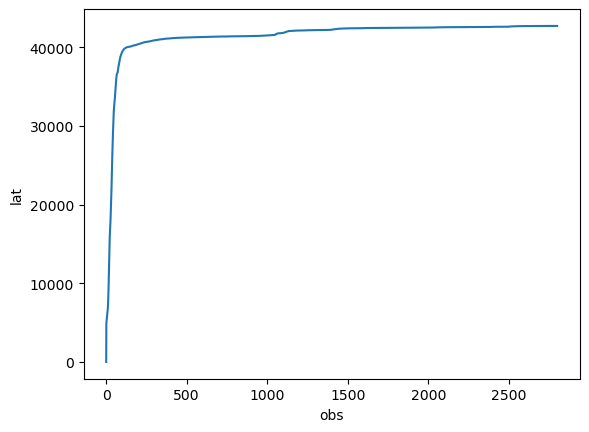

In [4]:
ds_traj.lat.isnull().sum('trajectory').plot(label='A grid')

In [ ]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

for n in range(ds_traj.sizes["trajectory"]):
    ax.plot(
        *ds_traj.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="g", alpha=0.1,
        transform=ccrs.PlateCarree(),
    )

ax.coastlines()
ax.set_extent([
    np.min(fieldset.U.grid.lon),
    np.max(fieldset.U.grid.lon),
    np.min(fieldset.U.grid.lat),
    np.max(fieldset.U.grid.lat),
])
ax.gridlines(draw_labels=True);
